1. The Residual Plots

The frank model generates synthetic visibilities, which are subtracted from the observed visibilities to produce residual visibilities. These residuals are then imaged using the CLEAN algorithm, resulting in a residual map. Like other radio continuum images, this map has units of flux density per beam (e.g., Jy/beam). To express the residuals in terms of signal-to-noise ratio (SNR), as done in Figure 3 of the exoALMA IV paper, the observed rms noise corresponding to each robust weighting must be extracted from the original image and used to rescale the residual flux densities.

However, since protoplanetary disks are best studied in concentric radial rings from the central star, it's important to consider that the noise level varies with radius. At larger disk radii, more ALMA beams cover each ring, which reduces the azimuthally averaged noise. In contrast, the inner disk tends to show brighter emission but fewer independent beams per bin. Therefore, the azimuthally averaged rms noise within each radial ring provides the most effective way to separate planet-induced substructure signals from noise.

In [111]:
# add autoreload

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [112]:
# import necessary libraries

import os  
import sys
import numpy as np  
import re  # Python’s regular expressions module to extract numbers from filenames
from astropy.io import fits
import pandas as pd
from gofish import imagecube
import matplotlib.pyplot as plt
import glob   # to find files matching a pattern
from reproject import reproject_interp
from IPython.display import display
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
 
import pickle # to save and load Python objects

# 
#from disk_residuals_median_SNR import DiskResiduals_Median_SNR as DiskResiduals


sys.path.insert(0, os.path.abspath('.'))

import disk_residuals_median_SNR
import importlib
importlib.reload(disk_residuals_median_SNR)
DiskResiduals = disk_residuals_median_SNR.DiskResiduals_Median_SNR


In [113]:
# load the all_disk object 

### Chapter 1: Compute and Plot the Residual Profiles 

In [114]:

# load the all_disk object  (does not have source_detection yet) 

with open('disk_object_files/all_disks.pkl', 'rb') as f:
    all_disks = pickle.load(f)


In [115]:
def plot_profiles_new(self, robust_val="1.0", FOV=None, radius_unit="arcsec", use_full_fov=False, figsize=(12, 6), all_disks=None ):
        """
        Plot radial profiles for one disk (default) or all disks (if all_disks is provided).
        If all_disks is dict: plot all disks in subplots (3x5), shared y-axis, individual x-axis, no legend.
        """
        import numpy as np
        import matplotlib.pyplot as plt
        from matplotlib.ticker import MaxNLocator , LogLocator
        def _plot_single_disk_profile(disk_obj, ax, robust_val, FOV, radius_unit, use_full_fov):
            r = disk_obj._rkey(robust_val)
            if not disk_obj.has_robust(r):
                ax.set_title(f"{disk_obj.name}\n[Missing robust {r}]")
                ax.axis('off')
                ax.set_yticks([])
                return

            # Load cubes
            if use_full_fov:
                cube_clean = disk_obj.get_cube("2.0", cube_type="clean", use_full_fov=True)
                cube_clean = disk_obj.mask_inner_region(cube_clean, factor=2.0)
                cube_resid = None
            else:
                cube_clean = disk_obj.get_cube(r, FOV=FOV, cube_type="clean")
                cube_resid = disk_obj.get_cube(r, FOV=FOV, cube_type="residual")

            # CLEAN radial profile
            x_cl, y_cl, dy_cl = cube_clean.radial_profile(
                inc=disk_obj.inc, PA=disk_obj.PA, unit='Jy/beam',
                assume_correlated=True, use_mad=True
            )

            # If using full FOV, optionally crop to outer disk region
            if use_full_fov and hasattr(disk_obj, "disksize"):
                r90 = float(disk_obj.disksize.get("R90", 0))
                if r90 > 0:
                    # Convert 2×R90 into the same units as x_cl
                    scale = disk_obj.distance_pc if radius_unit == "au" else 1.0
                    x_min = 2.0 * r90 * scale
                    mask = x_cl >= x_min
                    if np.any(mask):  # only apply if not all False
                        x_cl, y_cl, dy_cl = x_cl[mask], y_cl[mask], dy_cl[mask]
            
            
            
            # Residual radial profile
            if (not use_full_fov) and (cube_resid is not None):
                x_res, y_res, dy_res = cube_resid.radial_profile(
                    inc=disk_obj.inc, PA=disk_obj.PA, unit='Jy/beam',
                    assume_correlated=True, use_mad=True
                )
            else:
                x_res = y_res = dy_res = None

            # Radius units
            if radius_unit == "au":
                x_cl = x_cl * disk_obj.distance_pc
                if x_res is not None:
                    x_res = x_res * disk_obj.distance_pc
                xlabel = "Radius (au)"
                gap_unit_factor = disk_obj.distance_pc
            else:
                xlabel = "Radius (arcsec)"
                gap_unit_factor = 1.0

            if (not use_full_fov):
                if hasattr(disk_obj, "disksize"):
                    R90 = disk_obj.disksize["R90"] * gap_unit_factor
                    err_low = disk_obj.disksize.get("R90_err_low", 0.0) * gap_unit_factor
                    err_high = disk_obj.disksize.get("R90_err_high", 0.0) * gap_unit_factor
                    ax.axvline(R90, color='k', linestyle='--')
                    if (err_low > 0) or (err_high > 0):
                        ax.axvspan(R90 - err_low, R90 + err_high, color='k', alpha=0.15)
                    
                    ax.text(
                        0.95, 0.95,
                        f"$R_{{90}} = {R90:.2f}$ {radius_unit}",
                        transform=ax.transAxes,
                        ha='right', va='top',
                        fontsize=12, color='k',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
                    )
            # Plot
            if use_full_fov:
                ax.plot(x_cl, y_cl, color='gray', linewidth=2)
                ax.plot(x_cl, dy_cl, color='crimson', linewidth=2)
            else:
                ax.plot(x_cl, y_cl, color='gray', alpha = 0.3, linewidth=2)
                # ax.errorbar(x_cl, y_cl, dy_cl, fmt='none', ecolor='gray', alpha=0.5, capsize=2)
                if x_res is not None:
                    ax.plot(x_res, dy_res, color='crimson', linewidth=2)
            
            ax.set_yscale('log')
            #ax.yaxis.set_major_locator(MaxNLocator(nbins=6))  # Set max 4 major ticks
            #ax.set_ylabel('Intensity (Jy/beam)')
            ax.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
            ax.yaxis.set_minor_locator(plt.NullLocator())
            ax.set_title(disk_obj.name.replace("_", " "))


        
        # --- Main logic ---
        if all_disks is None:
            fig, ax = plt.subplots(constrained_layout=True, figsize=figsize)
            _plot_single_disk_profile(self, ax, robust_val, FOV, radius_unit, use_full_fov)
            ax.set_xlabel("Radius (au)" if radius_unit == "au" else "Radius (arcsec)")
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
            plt.show()
        else:
            disk_names = list(all_disks.keys())
            n_disks = len(disk_names)
            ncols = 3
            nrows = 5
            fig, axes = plt.subplots(nrows, ncols, figsize=(12, 15), sharey=True)
            axes = axes.flatten()
            for i, disk_name in enumerate(disk_names):
                disk_obj = all_disks[disk_name]
                _plot_single_disk_profile(disk_obj, axes[i], robust_val, FOV, radius_unit, use_full_fov)
                # Only set x-label for bottom row
                if i == ncols * nrows - ncols:  # bottom left index
                    axes[i].set_xlabel("Radius (au)" if radius_unit == "au" else "Radius (arcsec)")
                    axes[i].set_ylabel("Intensity (Jy/beam)")
            for ax in axes[n_disks:]:
                ax.axis('off')
            plt.tight_layout()
            plt.show()

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal aver

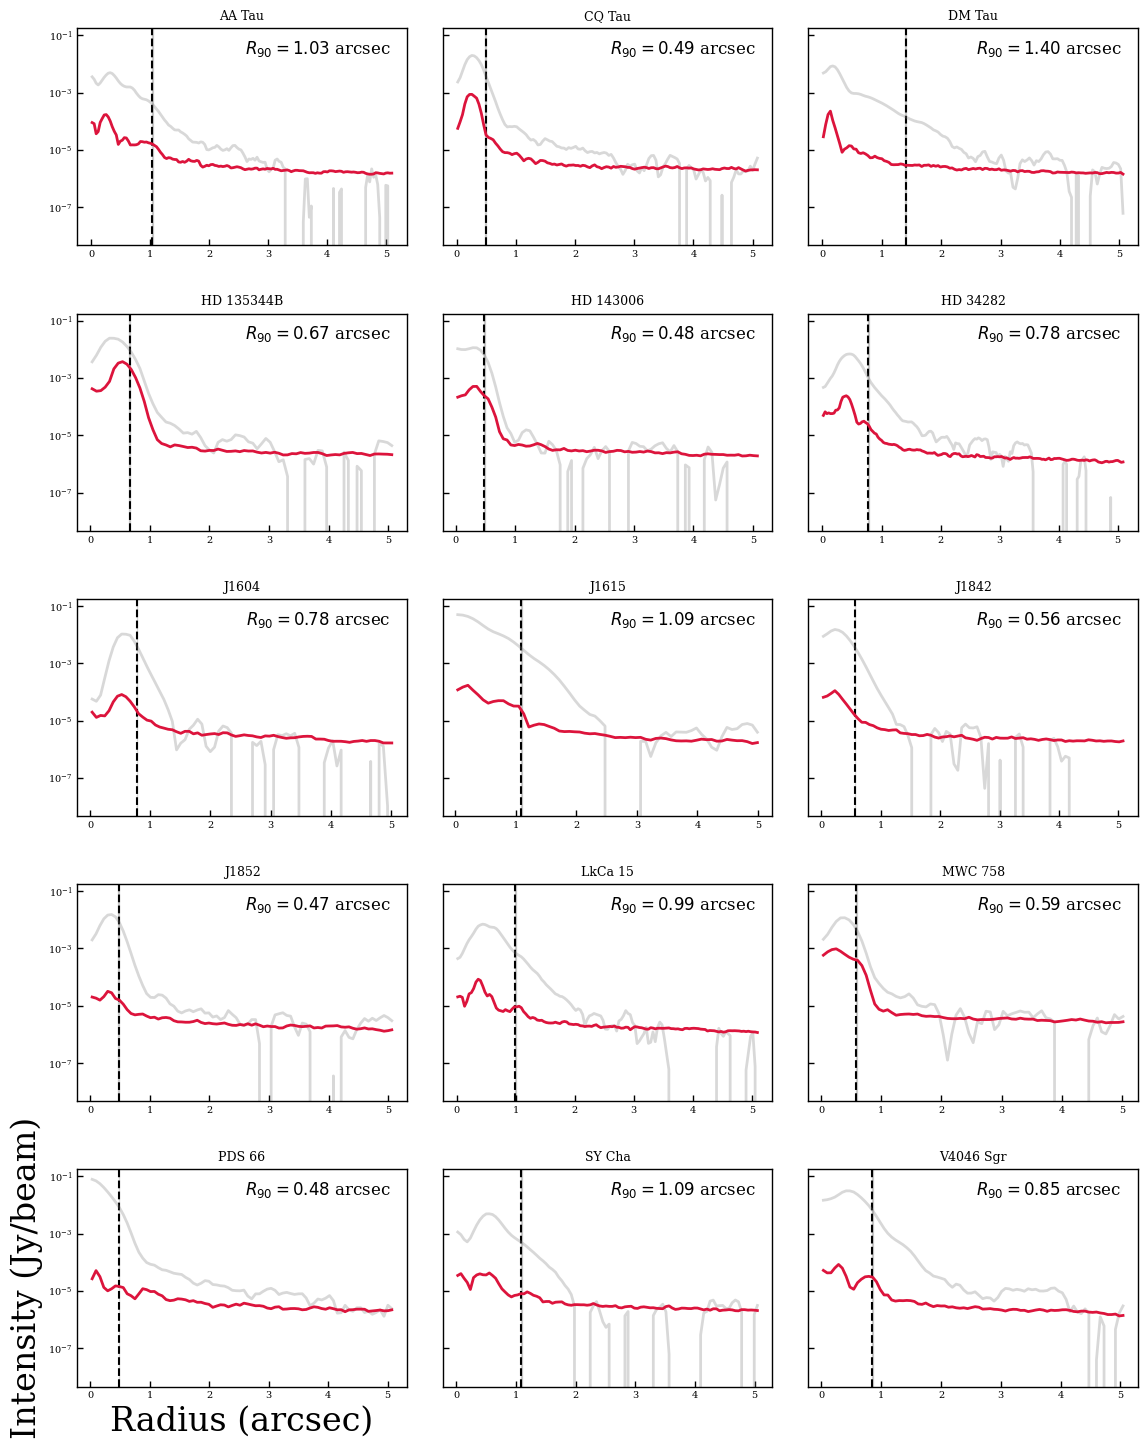

In [116]:

plot_profiles_new(None, robust_val="2.0", FOV=None, radius_unit="arcsec", use_full_fov=False, figsize=(12, 6), all_disks=all_disks)

### Chapter 2: Gaps

The origin of the gaps: how are they discovered. And the 

In [117]:
def plot_inner_profiles_with_gaps(all_disks, robust_val="1.0", radius_unit="au", figsize=(12, 15)):
    import matplotlib.pyplot as plt
    import numpy as np

    # Manuscript-style formatting
    plt.rcParams.update({
        "font.size": 8,
        "axes.linewidth": 0.8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.titlesize": 9,
    })

    disk_names = list(all_disks.keys())
    n_disks = len(disk_names)
    ncols = 3
    nrows = 5
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = axes.flatten()

    for i, disk_name in enumerate(disk_names):
        disk_obj = all_disks[disk_name]
        ax = axes[i]

        # Load CLEAN radial profile
        rkey = disk_obj._rkey(robust_val)
        cube_clean = disk_obj.get_cube(rkey, cube_type="clean")
        x_cl, y_cl, dy_cl = cube_clean.radial_profile(
            inc=disk_obj.inc, PA=disk_obj.PA, unit='Jy/beam',
            assume_correlated=True, use_mad=True
        )

        # Mask beyond R90
        if hasattr(disk_obj, "disksize"):
            R90 = disk_obj.disksize["R90"] * (disk_obj.distance_pc if radius_unit == "au" else 1.0)
            mask = (x_cl * (disk_obj.distance_pc if radius_unit == "au" else 1.0)) <= R90
            x_cl = x_cl[mask]
            y_cl = y_cl[mask]

        # Convert radius
        if radius_unit == "au":
            x_cl = x_cl * disk_obj.distance_pc
            xlabel = "Radius (au)"
        else:
            xlabel = "Radius (arcsec)"

        # Plot CLEAN profile
        ax.plot(x_cl, y_cl, color="crimson", linewidth=1.6)

        # -------------------------
        # Gap / Ring annotation
        # -------------------------
        if hasattr(disk_obj, "ringgap") and disk_obj.ringgap is not None and disk_obj.ringgap.size > 0:
            rg = disk_obj.ringgap
            if rg.ndim == 1:
                rg = rg[np.newaxis, :]

            # Get axis limits
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()

            # Three tiers, close to the curve, clean
            tiers = [
                ymin + 0.70*(ymax - ymin),
                ymin + 0.60*(ymax - ymin),
                ymin + 0.50*(ymax - ymin),
            ]

            # Minimum horizontal spacing between labels
            min_dx = 0.05 * (xmax - xmin)   # 5% axis width

            # Sort by increasing radius
            rg_sorted = rg[np.argsort(rg[:, 0 if radius_unit=="au" else 1])]

            # Keep track of last label position in each tier
            last_x = [-1e9, -1e9, -1e9]

            for row in rg_sorted:

                # Radius + width
                if radius_unit == "au":
                    rad  = row[0]
                    width = None if np.isnan(row[3]) else row[3]
                else:
                    rad  = row[1]
                    width = None if np.isnan(row[4]) else row[4]

                flag = int(row[2])
                prefix = "B" if flag == 1 else "D"

                # Colors
                linecolor = "#4d794d" if flag == 1 else "#6b5b95"
                spancolor = linecolor + "44"

                # Span
                if width is not None and width > 0:
                    ax.axvspan(rad - width/2, rad + width/2, color=spancolor, lw=0)

                # Vertical line
                ax.axvline(rad, color=linecolor, linestyle=":", linewidth=1.1)

                # Pick the FIRST tier where the x separation is large enough
                for k in range(3):
                    if rad - last_x[k] >= min_dx:
                        tier_y = tiers[k]
                        last_x[k] = rad
                        break
                else:
                    # If all tiers are too close, force last tier
                    tier_y = tiers[-1]

                # Slight x offset
                xoff = 0.01 * (xmax - xmin)
                label_x = rad + xoff

                if label_x > xmax * 0.97:
                    ha = "right"
                    label_x = rad - xoff
                else:
                    ha = "left"

                # Clean rotated label
                ax.text(
                    label_x, tier_y,
                    f"{prefix}-{int(rad)}",
                    rotation=28,
                    ha=ha, va="center",
                    fontsize=9,
                    color=linecolor,
                    alpha=0.85
                )

        # Title
        ax.set_title(disk_obj.name.replace("_", " "))

        # Bottom-left labels only
        row = i // ncols
        col = i % ncols
        if row == nrows - 1 and col == 0:
            ax.set_xlabel(xlabel, fontsize=12)
            ax.set_ylabel("Intensity (Jy/beam)", fontsize=12)
        else:
            ax.set_xlabel("")
            ax.set_ylabel("")

        #ax.set_xlim(np.min(x_cl), np.max(x_cl))
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(plt.LogLocator(base=10, numticks=4))
        ax.yaxis.set_minor_locator(plt.NullLocator())

    # Hide unused axes
    for ax in axes[n_disks:]:
        ax.axis("off")

    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    plt.show()


	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal aver

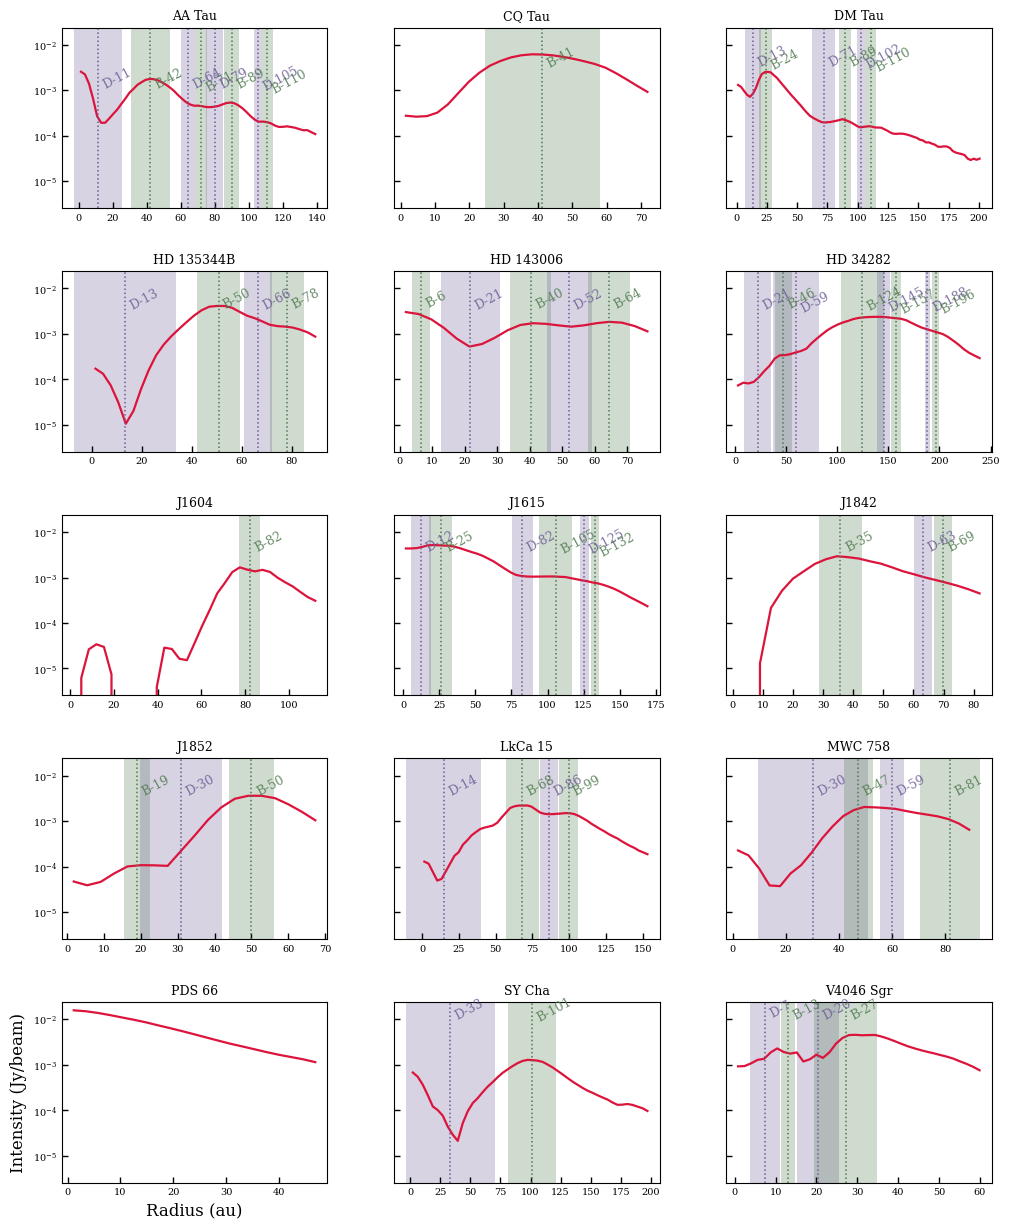

In [118]:
plot_inner_profiles_with_gaps(all_disks, robust_val="-0.5", radius_unit="au", figsize=(12, 15))

### Chapter 3. Data...Model...Residual...

In [119]:
# Load everything as fits if possible   , easier to manipulate 
# data, SNR model , SNR plot
# a zzomed in plot for the sources 
# SNR_FITS in D:\CPD_MPIA\Median_SNR\SNR_FITS_Maps\AA_Tau_SNR_robust2.0.fits
# Noise Fits in D:\CPD_MPIA\Median_SNR\Disk_Residual_Profile_Median_SNR\AA_Tau\AA_Tau_sigma_mask_robust2.0.fits 
# original resiudal fits in exoALMA data    D:\exoALMA_disk_data\AA_Tau\images_frank_residuals_different_robust/AA_Tau_continuum_resid_robust2.0.image.fits

# Load fits

import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

disk_names = list(all_disks.keys())

data_dir = "D:/exoALMA_disk_data"
model_dir = "D:/CPD_MPIA/Median_SNR/Disk_Residual_Profile_Median_SNR"
snr_dir = "D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps"

def get_fits_path(disk, kind):
    if kind == "Residual":
        return os.path.join(data_dir, disk, "images_frank_residuals_different_robust", f"{disk}_continuum_resid_robust2.0.image.fits")
    elif kind == "Noise":
        return os.path.join(model_dir, disk, f"{disk}_sigma_mask_robust2.0.fits") # adjust filename as needed
    elif kind == "SNR":
        return os.path.join(snr_dir, f"{disk}_SNR_robust2.0.fits")
    else:
        raise ValueError("Unknown kind")

from astropy.wcs import WCS
from matplotlib.patches import Ellipse

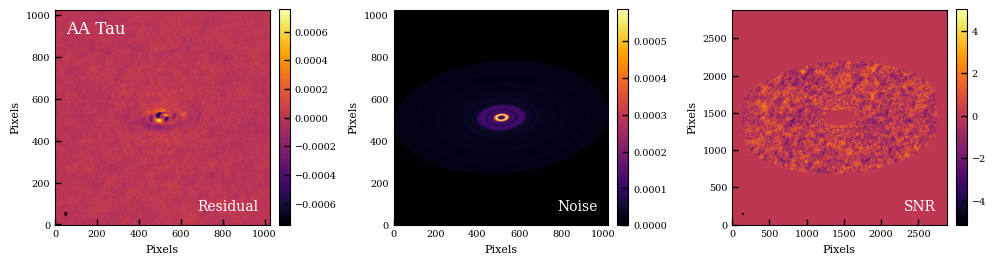

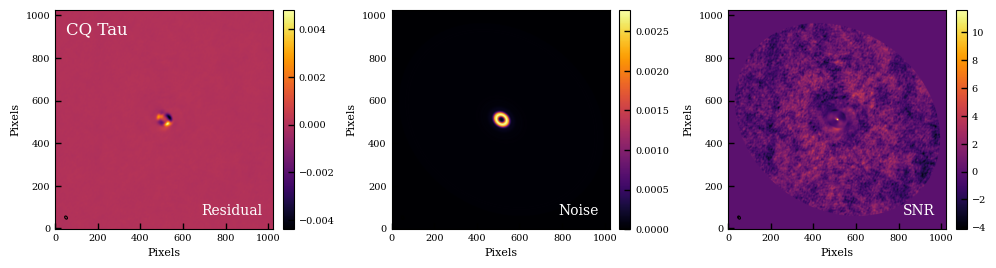

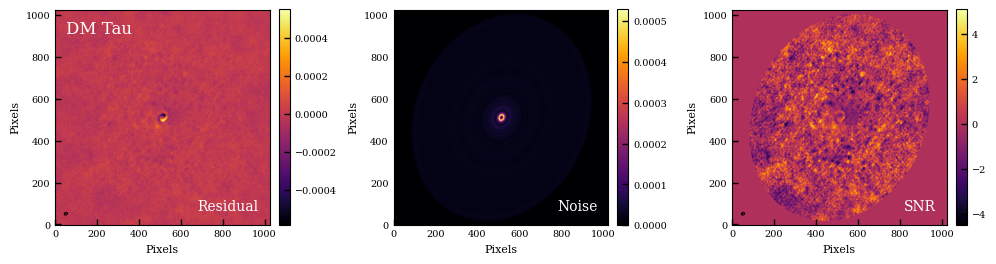

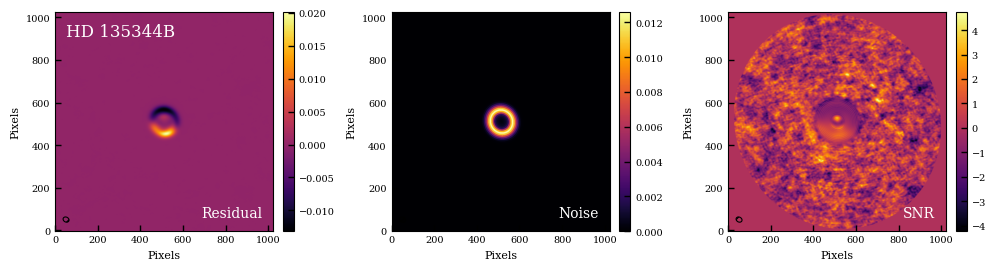

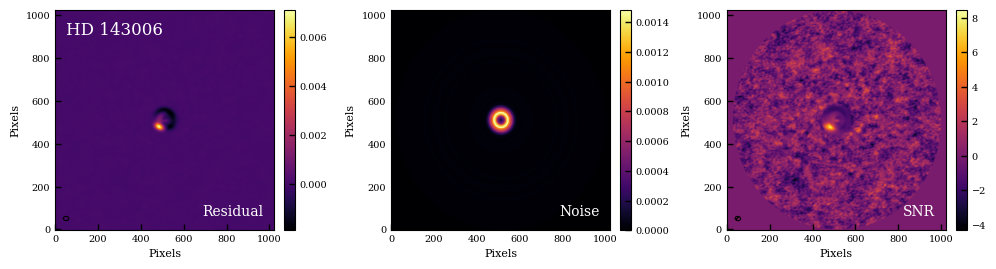

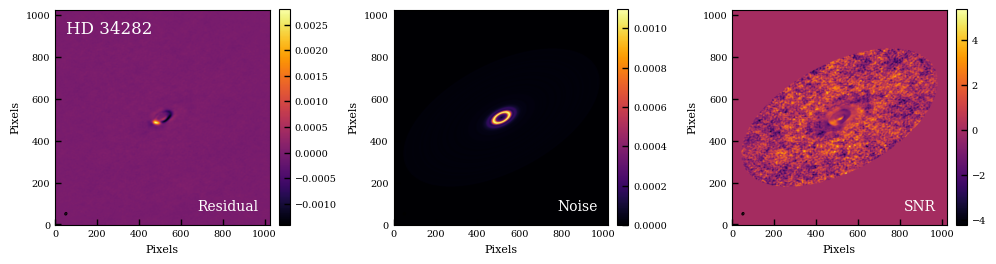

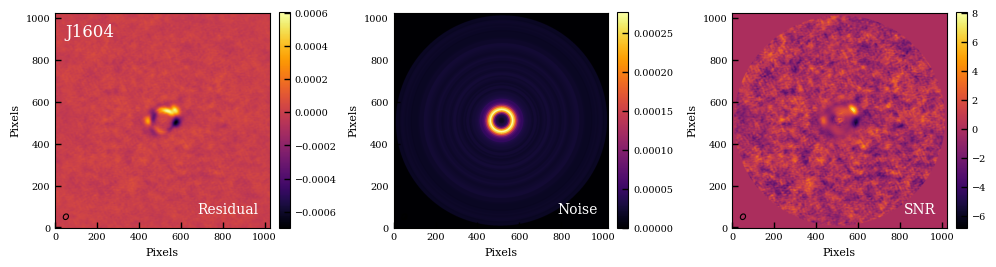

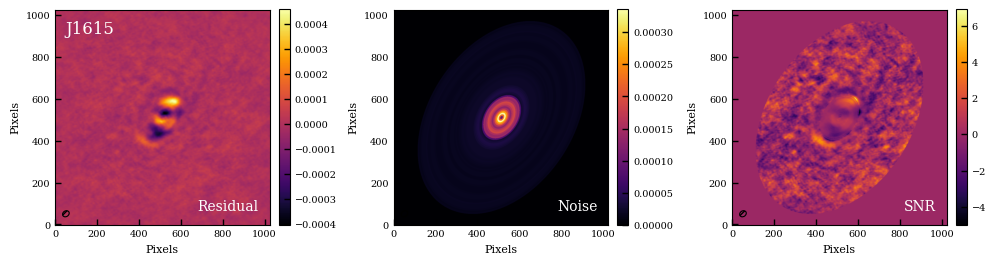

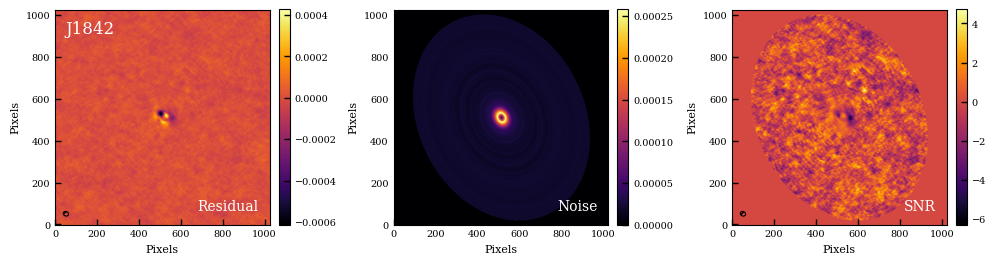

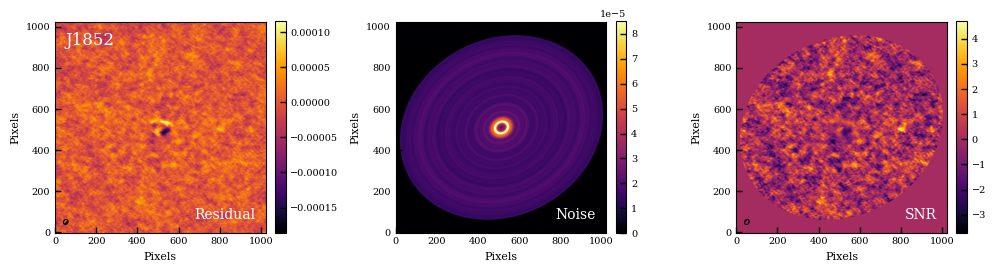

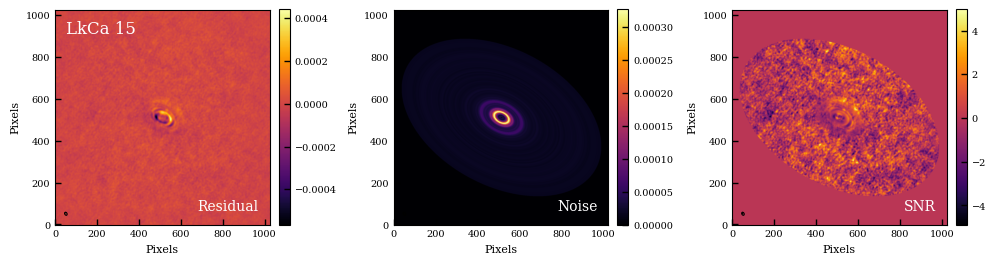

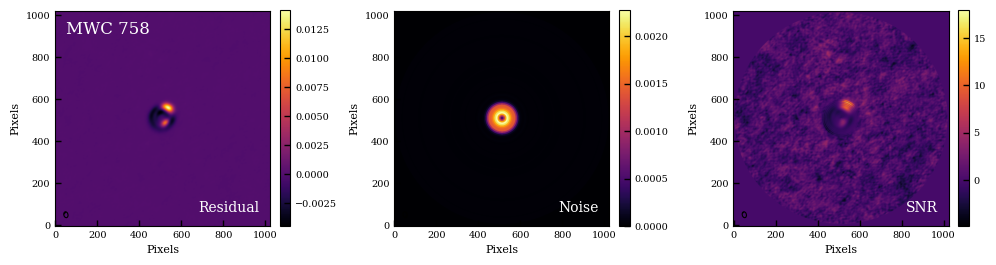

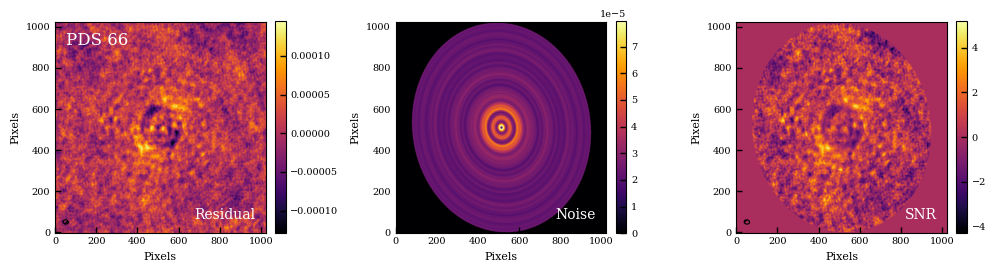

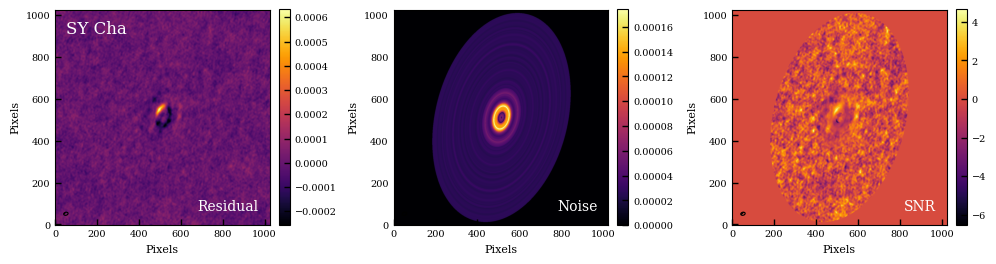

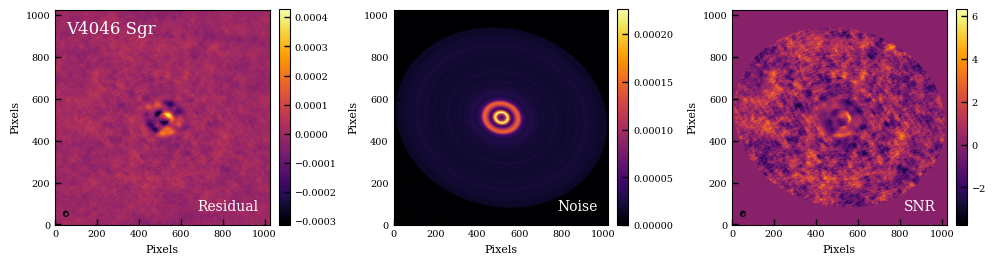

In [120]:
# Load everything as fits if possible   , easier to manipulate 
# data, SNR model , SNR plot
# a zzomed in plot for the sources 
# SNR_FITS in D:\CPD_MPIA\Median_SNR\SNR_FITS_Maps\AA_Tau_SNR_robust2.0.fits
# Noise Fits in D:\CPD_MPIA\Median_SNR\Disk_Residual_Profile_Median_SNR\AA_Tau\AA_Tau_sigma_mask_robust2.0.fits 
# original resiudal fits in exoALMA data    D:\exoALMA_disk_data\AA_Tau\images_frank_residuals_different_robust/AA_Tau_continuum_resid_robust2.0.image.fits

# Load fits


for disk in disk_names:
    fig, axes = plt.subplots(1, 3, figsize=(10, 4), squeeze=False)
    for j, kind in enumerate(["Residual", "Noise", "SNR"]):
        ax = axes[0, j]
        fits_path = get_fits_path(disk, kind)
        if os.path.exists(fits_path):
            img = fits.getdata(fits_path)
            img = np.squeeze(img)
            if img.ndim > 2:
                img = img[-1, -1, :, :]
            im = ax.imshow(img, origin='lower', cmap='inferno')
            
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            # add label at lower right
            ax.text(0.95, 0.05, kind,
                    transform=ax.transAxes,
                    ha='right', va='bottom',
                    fontsize=10, color='white')
            
        # Add unit, and xy values
        ax.set_xlabel("Pixels")
        ax.set_ylabel("Pixels")

        # --- Beam ellipse ---
        hdr = fits.getheader(fits_path)
        nx,ny = hdr['NAXIS1'], hdr['NAXIS2']
        disk_obj = all_disks[disk]
        beam_x_arcsec = float(hdr['BMAJ']) * 3600.0
        beam_y_arcsec = float(hdr['BMIN']) * 3600.0
        pix_scale_arcsec = abs(float(hdr['CDELT1'])) * 3600.0
        beam_width_pix = beam_x_arcsec / pix_scale_arcsec
        beam_height_pix = beam_y_arcsec / pix_scale_arcsec
        beam = Ellipse(
                xy=(0.05 * nx, 0.05 * ny),
                width=beam_width_pix,
                height=beam_height_pix,
                angle=-disk_obj.PA,
                facecolor='none',
                edgecolor='Black',
                hatch='///',
                lw=0.8
            )
        ax.add_patch(beam)   
        
    # Add label inside plot
    axes[0,0].text(0.05, 0.95, disk.replace("_", " "),
                    transform=axes[0,0].transAxes,
                    ha='left', va='top',
                    fontsize=12, color='white',
                    )
    
    # Add 
    
    plt.tight_layout()
    plt.show()


### Chapter 4: Zoomed-In of The Sources

- Issue:  beam is too big in zoomed in image and too small in zoomed out image
- hid all the axes label and set them in the big plot

Example way to call  the zhu model

```python
# 2. Compute flux for a fixed Rout/RH (e.g., 0.3)
Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
for i, Mdot in enumerate(Mdot_grid):
    for j, Mp in enumerate(Mp_grid):

        RHill = rD22 * (Mp / (3 * 1047.56 * HD1423006_disk_arr[1]))**(1/3)
        Rout = 0.3 * RHill

        out = calculate_disk_properties_zhu(
            M_star = HD1423006_disk_arr[1],
            Mp = Mp,
            Mdot = Mdot,
            alpha = 1e-2,
            rp = rD22,
            d_pc = HD1423006_disk_arr[2],
            lam_mm = 1.25,
            Rout = Rout,
            Lstar = HD1423006_disk_arr[3],
        )

        Flux_vals[i, j] = out["F_nu_tot"]

# 3. Plot
plot_zhu_Mp_Mdot_flux(
    Mp_grid, Mdot_grid, Flux_vals,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-2,
    target_flux_arr=HD1423006_target_flux_arr
)

```

In [121]:
# import the model.py files

import sys
import os

# Add the CPD_Emission_Models directory to the Python path
model_dir = r'D:\CPD_MPIA\CPD_Emission_Models'
if model_dir not in sys.path:
    sys.path.append(model_dir)

# Now import the modules
import Zhu_model
import Andrew_model
import Dictionaries
 

In [122]:
import os
for f in os.listdir():
    print(repr(f))

'Disk_Residual_Profile_Median_SNR'
'SNR_FITS_Maps'
'source_detection_outer.txt'
'disk_obj.pkl'
'all_disks.pkl'
'Residual_Plot.ipynb'
'disk_residuals_median_SNR.py'
'__pycache__'
'Plotting.ipynb'
'gaps_summary.pkl'
'all_disk_dicts.pkl'
'Disk_Object.ipynb'
'Residual_Plot copy.ipynb'
'Plot.ipynb'
'Source_Detection.ipynb'
'five_sigma_detections.csv'
'disk_object_files'
'Get_Sigma_At_R.ipynb'
'Andrews'
'Dictionaries.py'
'CPD_summary_plot.pdf'
'CPD_summary_plot.png'


In [140]:
from matplotlib.patches import Circle, Ellipse

def plot_snr_zoom(ax, img, hdr, zoom_arcsec=0.1,
                  disk_centroid=(1000,1000), area=500):

    img = np.squeeze(img)
    ny, nx = img.shape

    # Pixel scale in arcsec
    if "CDELT1" in hdr:
        pix_scale = abs(hdr["CDELT1"]) * 3600.0
    elif "CD1_1" in hdr:
        pix_scale = abs(hdr["CD1_1"]) * 3600.0

    # Centre
    x0, y0 = disk_centroid

    # Zoom in pixels
    zoom_pix = int(zoom_arcsec / pix_scale)

    x1, x2 = max(0, x0 - zoom_pix), min(nx, x0 + zoom_pix)
    y1, y2 = max(0, y0 - zoom_pix), min(ny, y0 + zoom_pix)

    sub = img[y1:y2, x1:x2]

    # -------- EXTENT IN ARCSEC instead of pixels ----------
    extent = [
        (x1 - x0) * pix_scale,
        (x2 - x0) * pix_scale,
        (y1 - y0) * pix_scale,
        (y2 - y0) * pix_scale
    ]

    im = ax.imshow(sub, origin='lower', cmap='RdBu_r', extent=extent)

    # Circle (area in pixels → convert to arcsec)
    pix_radii = np.sqrt(area / np.pi)
    arcsec_radii = pix_radii * pix_scale

    center_circle = Circle((0, 0), radius=arcsec_radii,
                           facecolor='none', edgecolor='black',
                           linestyle='--', linewidth=1.2)
    ax.add_patch(center_circle)

    # ---- Beam ellipse in arcsec ----
    if "BMAJ" in hdr and "BMIN" in hdr:
        bmaj_arc = hdr["BMAJ"] * 3600.0
        bmin_arc = hdr["BMIN"] * 3600.0
        bpa      = hdr.get("BPA", 0.0)

        # place in bottom-left corner
        beam_x = extent[0] + 0.15 * (extent[1]-extent[0])
        beam_y = extent[2] + 0.15 * (extent[3]-extent[2])

        beam = Ellipse((beam_x, beam_y),
                       width=bmin_arc, height=bmaj_arc,
                       angle=-disk_obj.PA,
                       facecolor='none', edgecolor='green',hatch='///', alpha=1.0, lw = 1.2)
        ax.add_patch(beam)


    ax.set_xticks([-zoom_arcsec, 0, zoom_arcsec])
    ax.set_yticks([-zoom_arcsec, 0, zoom_arcsec])
    ax.set_xlabel("ΔRA offset ('')", fontsize=rcParams['font.size'])
    ax.set_ylabel("ΔDec offset ('')", fontsize=rcParams['font.size'])
    ax.tick_params(labelsize=rcParams['font.size']*0.9)

    return im


In [141]:



def plot_snr_full_fov(ax, img, hdr,
                      disk_centroid=(1000, 1000), 
                      ):
    """
    Plot full-SNR map with axes in arcsec offsets,
    centred at disk centroid, with beam and circle.
    """

    img = np.squeeze(img)
    ny, nx = img.shape

    # pixel scale in arcsec / pixel
    if "CDELT1" in hdr:
        pix_scale = abs(hdr["CDELT1"]) * 3600.0
    elif "CD1_1" in hdr:
        pix_scale = abs(hdr["CD1_1"]) * 3600.0
    else:
        raise ValueError("No pixel scale in FITS header")

    if "CRPIX1" in hdr and "CRPIX2" in hdr:
        x0 = int(hdr["CRPIX1"])
        y0 = int(hdr["CRPIX2"])
    else:
        # fallback to image center
        ny, nx = img.shape
        x0 = nx // 2
        y0 = ny // 2

    x_cen, y_cen = disk_centroid
    # ---- Build RA/Dec offset grids (arcsec) ----
    ypix, xpix = np.indices((ny, nx))
    dx = (xpix - x0) * pix_scale
    dy = (ypix - y0) * pix_scale

    # ---- Plot full FOV in arcsec coordinates ----
    # extent = [xmin, xmax, ymin, ymax]
    extent = [dx.min(), dx.max(), dy.min(), dy.max()]

    # color scaling symmetric around 0
    vmax = np.nanmax(np.abs(img))
    im = ax.imshow(img, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax,
                   extent=extent)

    # magenta cross to denote the centroid
    ax.plot((x_cen - x0) * pix_scale, (y_cen - y0) * pix_scale, marker='+', color='magenta', markersize=12, mew=2)

    # ---- Beam ellipse in arcsec ----
    if "BMAJ" in hdr and "BMIN" in hdr:
        bmaj_arc = hdr["BMAJ"] * 3600.0
        bmin_arc = hdr["BMIN"] * 3600.0
        bpa      = hdr.get("BPA", 0.0)

        # place in bottom-left corner
        beam_x = extent[0] + 0.15 * (extent[1]-extent[0])
        beam_y = extent[2] + 0.15 * (extent[3]-extent[2])

        beam = Ellipse((beam_x, beam_y),
                       width=bmin_arc, height=bmaj_arc,
                       angle=bpa,
                       facecolor='white', alpha=0.7)
        ax.add_patch(beam)

    # ---- Axes formatting ----
    ax.set_xticks([-10, 0, 10])
    ax.set_yticks([-10, 0, 10])
    ax.set_xlabel("ΔRA offset ('')", fontsize=rcParams['font.size'])
    ax.set_ylabel("ΔDec offset ('')")
    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
    ax.tick_params(labelsize=rcParams['font.size']*0.9)


    return im


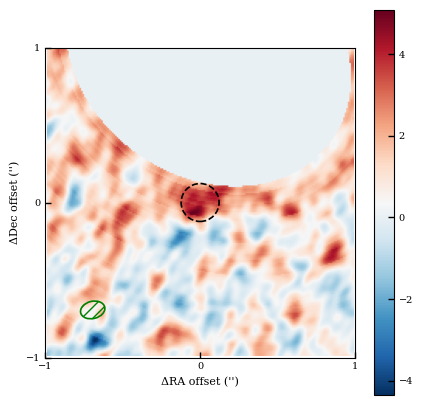

In [125]:
import matplotlib.pyplot as plt
from astropy.io import fits

snr_path = f"D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps/CQ_Tau_SNR_FullFOV_robust2.0.fits"

img = fits.getdata(snr_path)
hdr = fits.getheader(snr_path)

fig, ax = plt.subplots(figsize=(5, 5))

im = plot_snr_zoom(ax, img, hdr, 
                   zoom_arcsec=1,
                   disk_centroid=(1435, 1343), area=470)

plt.colorbar(im, ax=ax)
plt.show()

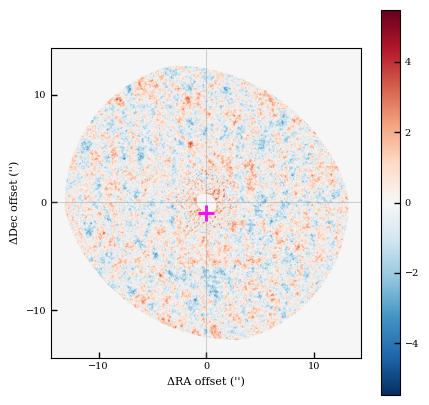

In [126]:
import matplotlib.pyplot as plt
from astropy.io import fits



fig, ax = plt.subplots(figsize=(5, 5))

im = plot_snr_full_fov(ax, img, hdr, 
                   disk_centroid=(1435, 1343))

plt.colorbar(im, ax=ax)
plt.show()

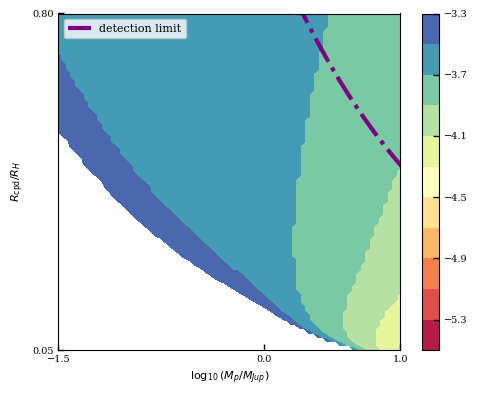

In [127]:
# Subplot for the Andrew model
import pandas as pd
disk_arr = Dictionaries.disk_arr
five_sigma_sources = Dictionaries.five_sigma_sources
csv_path = rf'D:\CPD_MPIA\CPD_Emission_Models\Andrews\CQ_Tau_165.37_alpha0.001_5sigma.csv'
df = pd.read_csv(csv_path)

Mp_grid = df['Mp_grid'].unique()
Rout_frac_grid = df['Rout_frac_grid'].unique()
Flux_vals = df.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values
M_cpd_chosen = df.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values
                                                  
fig, ax = plt.subplots(figsize=(5, 4))

cf = Andrew_model.plot_flux_map(
    Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen,
    disk_arr=disk_arr['CQ_Tau'],
    rp=165.37,
    alpha=1e-3,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['CQ_Tau'][4]*disk_arr['CQ_Tau'][2],
    sigma_ujy=five_sigma_sources[0][3],
    det_sigma=five_sigma_sources[0][5],
    ax = ax
)

plt.colorbar(cf, ax=ax)
plt.tight_layout()
plt.show()

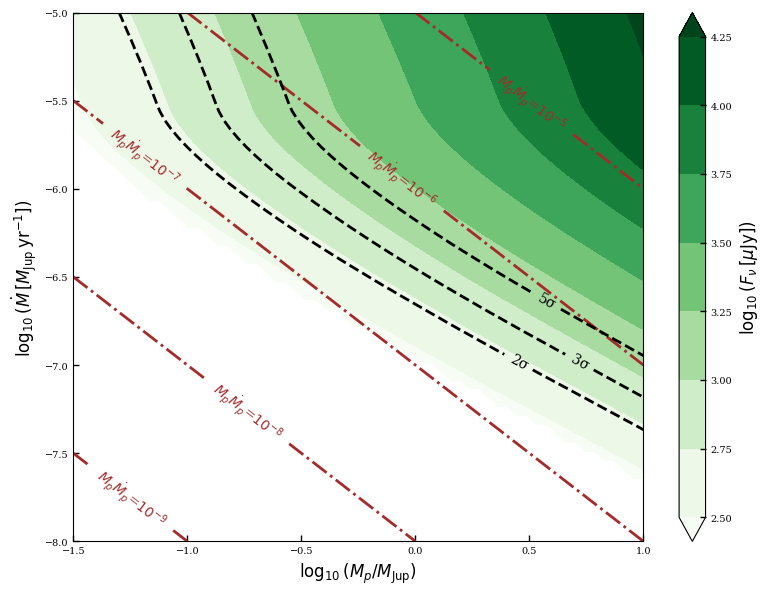

In [128]:
# zhu model 
Mp_grid = np.logspace(-1.5, 1, 60)       # 0.1–10 Mjup
Mdot_grid = np.logspace(-8, -5, 60)    # 1e-9 – 1e-5 Mjup/yr

Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
disk_arr = Dictionaries.disk_arr["CQ_Tau"]
for i, Mdot in enumerate(Mdot_grid):
    for j, Mp in enumerate(Mp_grid):

        RHill = five_sigma_sources[0][1] * (Mp / (3 * 1047.56 * disk_arr[1]))**(1/3)
        Rout = 0.3 * RHill

        out = Zhu_model.calculate_disk_properties_zhu(
            M_star = disk_arr[1],
            Mp = Mp,
            Mdot = Mdot,
            alpha = 1e-3,
            rp = five_sigma_sources[0][1],
            d_pc = disk_arr[2],
            lam_mm = 0.9,
            Rout = Rout,
            Lstar = disk_arr[3],
        )

        Flux_vals[i, j] = out["F_nu_tot"]

# 3. Plot
Zhu_model.plot_zhu_Mp_Mdot_flux(
    Mp_grid, Mdot_grid, Flux_vals,
    disk_arr=disk_arr,
    rp=five_sigma_sources[0][1],
    alpha=1e-3,
    target_flux_arr=[five_sigma_sources[0][2]]
)

In [134]:
disk_names = [
    'CQ_Tau',
    'CQ_Tau',
    'V4046_Sgr'
]
disk_radii = [
    165.37,   # CQ Tau r=165 au
    932.14,   # CQ Tau r=932 au
    837.63    # V4046 Sgr
]

disk_centroid =[(1435,1343), (1293,1991) , (1570, 2403)]  
disk_area =[470,  480,  764]

y_lim = [(0.05, 0.8), (0.05, 0.8), (0.01, 0.1)]

from Dictionaries import disk_arr, five_sigma_sources

In [ ]:
from matplotlib import rcParams

# ============================================================
# GLOBAL VISUAL STYLE
# ============================================================
rcParams["font.size"] = 14
rcParams["font.family"] = "serif"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"


fig, axes = plt.subplots(
    4, 3, figsize=(15, 18),
    sharex=False, sharey=False,
    gridspec_kw={'height_ratios': [1, 1, 1, 1]}   # <-- force all rows equal height
)

# -------------------------------------------------------
# Save ONE mappable per row for the row-level colorbar
# -------------------------------------------------------
row_mappables = [None, None, None, None]

for col, (disk_name, disk_radius, centroid, area , ylim) in enumerate(
        zip(disk_names, disk_radii, disk_centroid, disk_area, y_lim)):

    # =====================================================
    # ------------------------- ROW 1 ----------------------
    # =====================================================
    ax = axes[0, col]
    ax.set_aspect('equal', adjustable='box')

    img = fits.getdata(
        f'D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps/{disk_name}_SNR_FullFOV_robust2.0.fits'
    )
    hdr = fits.getheader(
        f'D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps/{disk_name}_SNR_FullFOV_robust2.0.fits'
    )

    im = plot_snr_zoom(ax, img, hdr, 1, centroid, area)

    if col == 2:     # save mappable from last column only
        row_mappables[0] = im


    # =====================================================
    # ------------------------- ROW 2 ----------------------
    # =====================================================
    ax = axes[1, col]
    ax.set_aspect('equal', adjustable='box')

    im = plot_snr_full_fov(ax, img, hdr, centroid)

    if col == 2:
        row_mappables[1] = im


    # =====================================================
    # ------------------------- ROW 3 ----------------------
    # =====================================================
    ax = axes[2, col]
    ax.set_aspect('auto')

    df = pd.read_csv(
        rf'D:\CPD_MPIA\CPD_Emission_Models\Andrews\{disk_name}_{disk_radius}_alpha0.001_5sigma.csv'
    )

    Mp_grid = df['Mp_grid'].unique()
    Rout_frac_grid = df['Rout_frac_grid'].unique()

    Flux_vals = df.pivot(
        index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals'
    ).values

    M_cpd_chosen = df.pivot(
        index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals'
    ).values

    im = Andrew_model.plot_flux_map(
         Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen,
         disk_arr=disk_arr[disk_name], ax=ax,
         rp=disk_radius, alpha=1e-3,
         x_min=-2, x_max=1,  
         y_min=ylim[0], y_max=ylim[1],
         res_au=disk_arr[disk_name][4] * disk_arr[disk_name][2],
         sigma_ujy=five_sigma_sources[col][3],
         det_sigma=five_sigma_sources[col][5],
    )

    if col == 2:
        row_mappables[2] = im


    # =====================================================
    # ------------------------- ROW 4 ----------------------
    # =====================================================
    ax = axes[3, col]
    ax.set_aspect('auto')

    Mp_grid = np.logspace(-2, 1, 100)
    Mdot_grid = np.logspace(-8, -5, 100)

    Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))

    for i, Mdot in enumerate(Mdot_grid):
        for j, Mp in enumerate(Mp_grid):

            RHill = five_sigma_sources[col][1] * (Mp / (3 * 1047.56 * disk_arr[disk_name][1]))**(1/3)
            Rout = 0.3 * RHill

            out = Zhu_model.calculate_disk_properties_zhu(
                M_star=disk_arr[disk_name][1],
                Mp=Mp,
                Mdot=Mdot,
                alpha=1e-3,
                rp=five_sigma_sources[col][1],
                d_pc=disk_arr[disk_name][2],
                lam_mm=0.9,
                Rout=Rout,
                Lstar=disk_arr[disk_name][3],
            )

            Flux_vals[i, j] = out["F_nu_tot"]

    im = Zhu_model.plot_zhu_Mp_Mdot_flux(
        Mp_grid, Mdot_grid, Flux_vals,
        disk_arr=disk_arr[disk_name],
        rp=disk_radius,
        alpha=1e-3,
        target_flux_arr=[five_sigma_sources[col][2]],
        ax=ax
    )

    if col == 2:
        row_mappables[3] = im



# ===============================================================
# ---------------- ONE COLORBAR PER ROW -------------------------
# ===============================================================

for row in range(4):

    ax_last = axes[row, -1]
    pos = ax_last.get_position()

    # place colorbar next to rightmost subplot
    cax = fig.add_axes([
        pos.x1 + 0.01,   # x-position
        pos.y0,          # y-position
        0.015,           # width
        pos.height       # height
    ])

    cb = fig.colorbar(row_mappables[row], cax=cax)

    # ---- optional labels per row ----
    if row == 0:
        cb.set_label("SNR (Zoomed Region)")
    elif row == 1:
        cb.set_label("SNR (Full FOV)")
    elif row == 2:
        # SIMPLE SHARED COLOR LIMITS FOR ROW 3
        row3_images = [axes[2, c].collections[0] for c in range(3)]
        row3_vmin = min(im.get_array().min() for im in row3_images)
        row3_vmax = max(im.get_array().max() for im in row3_images)

        for im in row3_images:
            im.set_clim(row3_vmin, row3_vmax)

        cb.mappable.set_clim(row3_vmin, row3_vmax)
        cb.set_label("Flux (Andrews Model)")
    elif row == 3:
        cb.set_label("Flux (Zhu Model)")

# ===============================================================
#          LEFT Y-LABELS FOR EACH ROW (PUBLICATION STYLE)
# ===============================================================

row_side_labels = [
    "SNR (Zoom)", "SNR (Full FOV)",
    "CPD Flux — Andrews Model",
    "CPD Flux — Zhu Model"
]

for row in range(4):
    axes[row,0].set_ylabel(
        row_side_labels[row], fontsize=13, labelpad=20
    )

# ===============================================================
#        ADD OVERALL COLUMN LABELS AT TOP
# ===============================================================
column_titles = ["CQ Tau (r=165 AU)", "CQ Tau (r=932 AU)", "V4046 Sgr (r=838 AU)"]
for col in range(3):
    axes[0, col].set_title(column_titles[col], fontsize=14, pad=10, fontweight='bold')

# ===============================================================
#     ADJUST SPACING FOR LABELS AND COLORBARS
# ===============================================================
plt.subplots_adjust(
    left=0.12,
    right=0.85,
    top=0.96,
    bottom=0.04,
    hspace=0.35,
    wspace=0.30
)


plt.show()


NameError: name 'img_list' is not defined

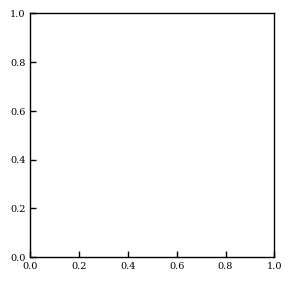

In [ ]:
from matplotlib import rcParams

# ============================================================
# GLOBAL VISUAL STYLE
# ============================================================
rcParams["font.size"] = 14
rcParams["font.family"] = "serif"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"


fig, axes = plt.subplots(
    4, 3, figsize=(15, 18),
    sharex=False, sharey=False,
)

# -------------------------------------------------------
# Save ONE mappable per row for the row-level colorbar
# -------------------------------------------------------
row_mappables = [None, None, None, None]

for col, (disk_name, disk_radius, centroid, area , ylim) in enumerate(
        zip(disk_names, disk_radii, disk_centroid, disk_area, y_lim)):

    # =====================================================
    # ------------------------- ROW 1 ----------------------
    # =====================================================
    ax = axes[0, col]
    ax.set_aspect('equal', adjustable='box')

    img = fits.getdata(
        f'D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps/{disk_name}_SNR_FullFOV_robust2.0.fits'
    )
    hdr = fits.getheader(
        f'D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps/{disk_name}_SNR_FullFOV_robust2.0.fits'
    )

    im = plot_snr_zoom(ax, img, hdr, 1, centroid, area)

    if col == 2:     # save mappable from last column only
        row_mappables[0] = im


    # =====================================================
    # ------------------------- ROW 2 ----------------------
    # =====================================================
    ax = axes[1, col]
    ax.set_aspect('equal', adjustable='box')

    im = plot_snr_full_fov(ax, img, hdr, centroid)

    if col == 2:
        row_mappables[1] = im


    # =====================================================
    # ------------------------- ROW 3 ----------------------
    # =====================================================
    ax = axes[2, col]
    ax.set_aspect('equal', adjustable='box')

    df = pd.read_csv(
        rf'D:\CPD_MPIA\CPD_Emission_Models\Andrews\{disk_name}_{disk_radius}_alpha0.001_5sigma.csv'
    )

    Mp_grid = df['Mp_grid'].unique()
    Rout_frac_grid = df['Rout_frac_grid'].unique()

    Flux_vals = df.pivot(
        index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals'
    ).values

    M_cpd_chosen = df.pivot(
        index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals'
    ).values

    im = Andrew_model.plot_flux_map(
         Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen,
         disk_arr=disk_arr[disk_name], ax=ax,
         rp=disk_radius, alpha=1e-3,
         x_min=-2, x_max=1,  
         y_min=ylim[0], y_max=ylim[1],
         res_au=disk_arr[disk_name][4] * disk_arr[disk_name][2],
         sigma_ujy=five_sigma_sources[col][3],
         det_sigma=five_sigma_sources[col][5],
    )

    if col == 2:
        row_mappables[2] = im


    # =====================================================
    # ------------------------- ROW 4 ----------------------
    # =====================================================
    ax = axes[3, col]
    ax.set_aspect('equal', adjustable='box')

    Mp_grid = np.logspace(-2, 1, 100)
    Mdot_grid = np.logspace(-8, -5, 100)

    Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))

    for i, Mdot in enumerate(Mdot_grid):
        for j, Mp in enumerate(Mp_grid):

            RHill = five_sigma_sources[col][1] * (Mp / (3 * 1047.56 * disk_arr[disk_name][1]))**(1/3)
            Rout = 0.3 * RHill

            out = Zhu_model.calculate_disk_properties_zhu(
                M_star=disk_arr[disk_name][1],
                Mp=Mp,
                Mdot=Mdot,
                alpha=1e-3,
                rp=five_sigma_sources[col][1],
                d_pc=disk_arr[disk_name][2],
                lam_mm=0.9,
                Rout=Rout,
                Lstar=disk_arr[disk_name][3],
            )

            Flux_vals[i, j] = out["F_nu_tot"]

    im = Zhu_model.plot_zhu_Mp_Mdot_flux(
        Mp_grid, Mdot_grid, Flux_vals,
        disk_arr=disk_arr[disk_name],
        rp=disk_radius,
        alpha=1e-3,
        target_flux_arr=[five_sigma_sources[col][2]],
        ax=ax
    )

    if col == 2:
        row_mappables[3] = im



# ===============================================================
# ---------------- ONE COLORBAR PER ROW -------------------------
# ===============================================================

for row in range(4):

    ax_last = axes[row, -1]
    pos = ax_last.get_position()

    # place colorbar next to rightmost subplot
    cax = fig.add_axes([
        pos.x1 + 0.01,   # x-position
        pos.y0,          # y-position
        0.015,           # width
        pos.height       # height
    ])

    cb = fig.colorbar(row_mappables[row], cax=cax)

    # ---- optional labels per row ----
    if row == 0:
        cb.set_label("SNR (Zoomed Region)")
    elif row == 1:
        cb.set_label("SNR (Full FOV)")
    elif row == 2:
        row_mappables[row].set_clim(-6, -2)   
        cb = fig.colorbar(row_mappables[row], cax=cax)
        cb.set_label("Flux (Andrews Model)")
    elif row == 3:
        cb.set_label("Flux (Zhu Model)")

# ===============================================================
#          LEFT Y-LABELS FOR EACH ROW (PUBLICATION STYLE)
# ===============================================================

row_side_labels = [
    "SNR (Zoom)", "SNR (Full FOV)",
    "CPD Flux — Andrews Model",
    "CPD Flux — Zhu Model"
]

for row in range(4):
    axes[row,0].set_ylabel(
        row_side_labels[row], fontsize=13, labelpad=20
    )

plt.tight_layout()
plt.show()


### Chapter 5: Inspecting the Imageloop Residuals

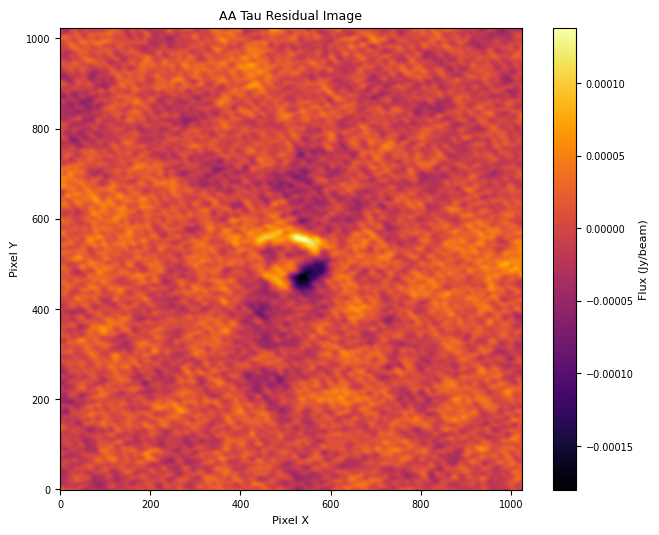

In [ ]:
# Plot and inspect a resid fit

# Plot a FITS image in Python
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

fits_path = r'D:\CPD_MPIA\Injection_Recovery_trial_fBf\J1852_robust2_0_gap0\resid_images\J1852_gap0.F34uJy_0000.resid.fits'
img = fits.getdata(fits_path)
img = np.squeeze(img)  # Remove extra dimensions if present

plt.figure(figsize=(8, 6))
plt.imshow(img, origin='lower', cmap='inferno')
plt.colorbar(label='Flux (Jy/beam)')
plt.title('AA Tau Residual Image')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()
